In [30]:
# shay dan

import numpy as np
import pandas as pd
import seaborn as sns
from scipy.special import ndtri
from matplotlib import pyplot as plt
from statsmodels.tsa.stattools import acf
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf

# Load data
path = "C:\\Users\\merda\\Downloads\\bitcoin.csv"
bitcoin = pd.read_csv(path)

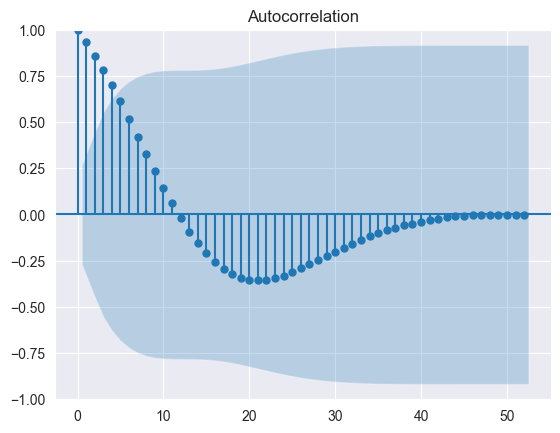

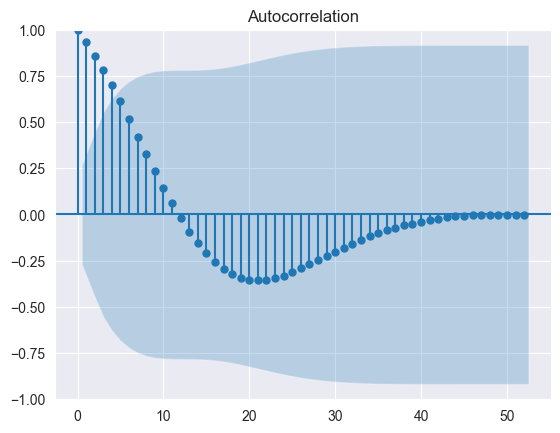

In [42]:
# Prepare Data
bitcoin["Date"] = pd.to_datetime(bitcoin.Timestamp, unit="s")
bitcoin = bitcoin.query(f'"2019-12-31" >= Date >= "2019-01-01"')
bitcoin.set_index("Date", inplace=True, drop=True)
bitcoin = bitcoin.resample("W").last().dropna()
acf_array = acf(bitcoin.Close,nlags=52)
plot_acf(acf_array, lags=52, alpha=0.05)


<BarContainer object of 53 artists>

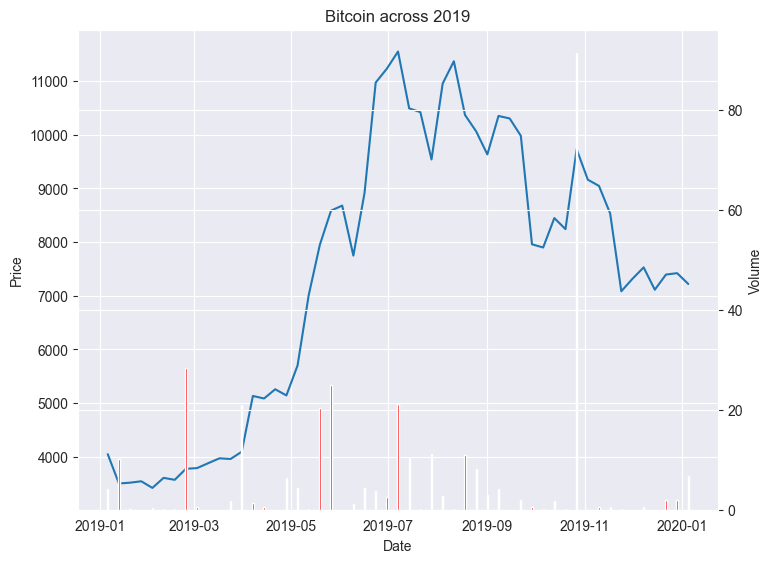

In [185]:
fig = plt.figure()
ax = fig.add_axes([0, 0, 1, 1])
ax.set_title("Bitcoin across 2019")
ax.set_xlabel("Date")
ax.set_ylabel("Price")
ax.plot(bitcoin.index, bitcoin.Close)
ax2 = ax.twinx()
ax2.set_ylabel("Volume")
ax2.bar(bitcoin.index, bitcoin.Volume, color="red")

In [193]:
significance = 0.05
bitcoin["Log_Price"] = np.log(bitcoin.Close)
dickie = adfuller(bitcoin.Log_Price)
print("The p-value of the test on bitcoin returns is:" + str(dickie[1]))
if dickie[1] < significance:
    print(
        f"The p-value is below {significance}, so we can easily reject the hypothesis that returns of bitcoin are a random walk at all levels of significance")
else:
    print("We cannot reject the null hypothesis "
          "that returns of bitcoin follow a random walk at all levels of significance")

The p-value of the test on bitcoin returns is:0.12268495584862316
We cannot reject the null hypothesis that returns of bitcoin follow a random walk at all levels of significance


(array([17897., 17956., 18017., 18078., 18140., 18201., 18262.]),
 [Text(17897.0, 0, '2019-01'),
  Text(17956.0, 0, '2019-03'),
  Text(18017.0, 0, '2019-05'),
  Text(18078.0, 0, '2019-07'),
  Text(18140.0, 0, '2019-09'),
  Text(18201.0, 0, '2019-11'),
  Text(18262.0, 0, '2020-01')])

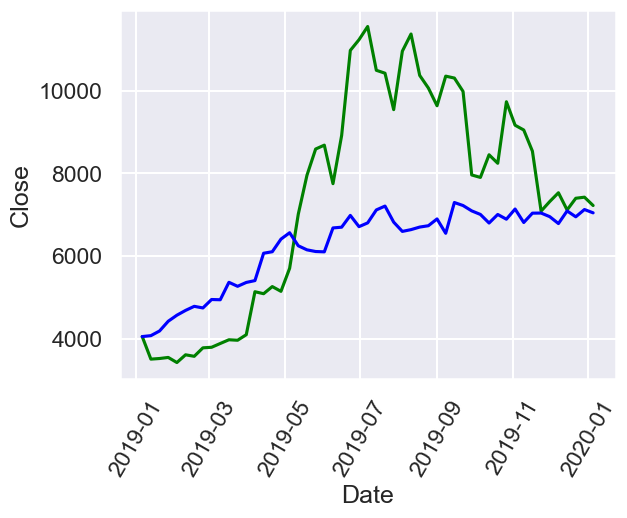

In [194]:
# random_walk = (steps - steps.min()) / (steps.max() - steps.min()) * (
#             bitcoin['Close'].max() - bitcoin['Close'].min()) + bitcoin['Close'].min()
# bitcoin["Random_Walk"] = random_walk
np.random.seed(1989)
steps = np.random.normal(0, bitcoin.Close.std() / 10, len(bitcoin))
steps[0] = bitcoin.Close.iloc[0]
results = np.cumsum(steps)
sns.set_theme()
sns.set_context('talk')
sns.lineplot(bitcoin, x="Date", y="Close", color="green")
sns.lineplot(bitcoin, x="Date", y=results, color="blue")
plt.xticks(rotation=60)

In [195]:
bitcoin["Monte_Prices"] = bitcoin.Close.iloc[0]
daily_return = bitcoin.Close.pct_change().dropna()
log_returns = np.log(daily_return + 1)
std = log_returns.std()
drift = log_returns.mean() - log_returns.var() / 2

random_values = drift + std * ndtri(np.random.random(len(bitcoin)))
bitcoin.Monte_Prices = (bitcoin.Close * np.exp(random_values))


(array([17897., 17956., 18017., 18078., 18140., 18201., 18262.]),
 [Text(17897.0, 0, '2019-01'),
  Text(17956.0, 0, '2019-03'),
  Text(18017.0, 0, '2019-05'),
  Text(18078.0, 0, '2019-07'),
  Text(18140.0, 0, '2019-09'),
  Text(18201.0, 0, '2019-11'),
  Text(18262.0, 0, '2020-01')])

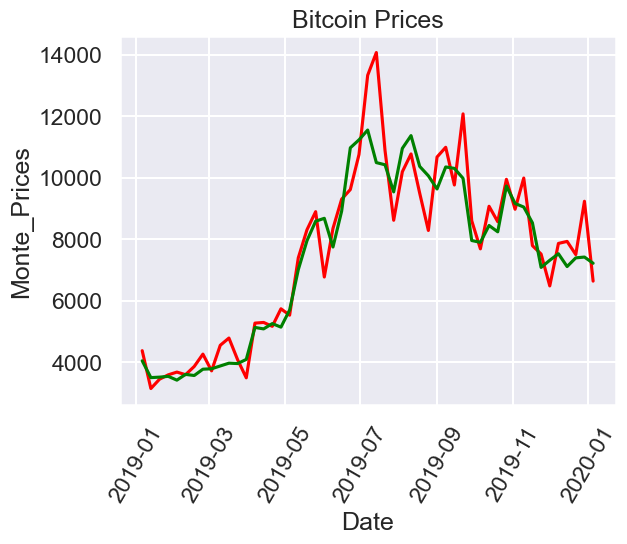

In [197]:
sns.set_theme()
sns.set_context('talk')
sns.lineplot(bitcoin, x="Date", y="Monte_Prices", color="red")
sns.lineplot(bitcoin, x="Date", y="Close", color="green")
sns.lineplot().set(title="Bitcoin Prices")
plt.xticks(rotation=60)

In [198]:
bitcoin["Log_Returns"] = np.log(daily_return + 1)
AR2_prices = bitcoin.Close.autocorr() ** 2
AR2_log_change = bitcoin.Log_Returns.autocorr() ** 2
print(AR2_prices)
print(AR2_log_change)



0.9252644368666252
0.0156694794729421
